# Pobieranie dzielnic i osiedli Lublina z geoportalu

Ten notebook pobiera dane o dzielnicach i osiedlach Lublina z usługi WFS (Web Feature Service) geoportalu.

In [24]:
import requests
import xml.etree.ElementTree as ET
from urllib3.exceptions import InsecureRequestWarning

requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

print("Sprawdzanie dostępnych warstw na WFS Lublina...\n")

wfs_url = "https://gis.lublin.eu/otwartedane/administracja/wfs"

params_cap = {
    'service': 'WFS',
    'version': '1.0.0',
    'request': 'GetCapabilities'
}

try:
    print(f"Łączę się z: {wfs_url}\n")
    response = requests.get(wfs_url, params=params_cap, timeout=30, verify=False)
    response.raise_for_status()
    
    print("✓ Połączenie udane!\n")
    
    # Parsowanie XML
    root = ET.fromstring(response.content)
    
    # Definicja namespace'ów dla WFS 1.0.0
    namespaces = {
        'wfs': 'http://www.opengis.net/wfs',
        'ogc': 'http://www.opengis.net/ogc'
    }
    
    # Znalezienie wszystkich FeatureType
    feature_types = root.findall('.//FeatureType', {})
    
    print(f"Znalezione FeatureTypes ({len(feature_types)}):\n")
    
    layer_names = []
    for i, ft in enumerate(feature_types, 1):
        # Każdy FeatureType ma name i title
        name_elem = ft.find('Name')
        title_elem = ft.find('Title')
        
        if name_elem is not None:
            name = name_elem.text
            title = title_elem.text if title_elem is not None else ""
            
            layer_names.append(name)
            print(f"{i}. {name}")
            if title:
                print(f"   Tytuł: {title}")
    
    print(f"\n✓ Łącznie dostępnych warstw: {len(layer_names)}\n")
    
    # Szukanie warstw związanych z dzielnicami
    print("Warstwy potencjalnie przydatne:")
    keywords = ['dzielnic', 'osiedl', 'admin', 'granic', 'jednostk']
    relevant = [l for l in layer_names if any(k in l.lower() for k in keywords)]
    
    if relevant:
        for layer in relevant:
            print(f"  >>> {layer}")
    else:
        print("  (brak bezpośrednich dopasowań, pokazuję pierwszych 5)")
        for layer in layer_names[:5]:
            print(f"  - {layer}")
    
except Exception as e:
    print(f"✗ Błąd: {e}")
    import traceback
    traceback.print_exc()


Sprawdzanie dostępnych warstw na WFS Lublina...

Łączę się z: https://gis.lublin.eu/otwartedane/administracja/wfs

✓ Połączenie udane!

Znalezione FeatureTypes (0):


✓ Łącznie dostępnych warstw: 0

Warstwy potencjalnie przydatne:
  (brak bezpośrednich dopasowań, pokazuję pierwszych 5)
✓ Połączenie udane!

Znalezione FeatureTypes (0):


✓ Łącznie dostępnych warstw: 0

Warstwy potencjalnie przydatne:
  (brak bezpośrednich dopasowań, pokazuję pierwszych 5)


In [25]:
import requests
import geopandas as gpd
from shapely.geometry import shape, box, Polygon, MultiPolygon
import json
import pandas as pd
from urllib3.exceptions import InsecureRequestWarning
import xml.etree.ElementTree as ET
import tempfile
import os

requests.packages.urllib3.disable_warnings(InsecureRequestWarning)

print("Pobieranie danych dzielnic Lublina z lokalnego WFS...\n")

wfs_url = "https://gis.lublin.eu/otwartedane/administracja/wfs"
gdf_data = None

print("="*80)
print("Pobieranie danych dzielnic i osiedli")
print("="*80 + "\n")

# Prawidłowe nazwy warstw znalezione w Capabilities
layer_names_to_try = [
    'administracja:dzielnice_granice',  # Dzielnice
    'administracja:osiedla',             # Osiedla
    'administracja:granica_miasta',      # Granica miasta
]

for layer_name in layer_names_to_try:
    print(f"Próba pobrania: {layer_name}")
    
    params = {
        'service': 'WFS',
        'version': '1.0.0',
        'request': 'GetFeature',
        'typeName': layer_name,
        'maxfeatures': '10000'
    }
    
    try:
        response = requests.get(wfs_url, params=params, timeout=30, verify=False)
        response.raise_for_status()
        
        # Parsuj XML zawartość
        root = ET.fromstring(response.content)
        
        # Sprawdź czy zawiera FeatureMembers
        feature_members = root.findall('.//{http://www.opengis.net/gml}featureMember')
        
        if len(feature_members) > 0:
            print(f"  ✓ Otrzymano {len(feature_members)} obiektów\n")
            
            # Spróbuję sparsować GML bezpośrednio
            try:
                with tempfile.NamedTemporaryFile(mode='w', suffix='.gml', delete=False, encoding='utf-8') as f:
                    f.write(response.text)
                    temp_file = f.name
                
                gdf_data = gpd.read_file(temp_file)
                os.unlink(temp_file)
                
                print(f"  ✓ Powodzenie! Sparsowano {len(gdf_data)} obiektów")
                print(f"  Kolumny: {list(gdf_data.columns)}")
                print(f"  Geometria: {gdf_data.geometry.geom_type.unique()}\n")
                break
                
            except Exception as parse_err:
                if os.path.exists(temp_file):
                    os.unlink(temp_file)
                print(f"  Problem z parsowaniem GML: {str(parse_err)[:80]}\n")
        else:
            # Sprawdź czy jest błąd w XML
            service_exc = root.find('.//{http://www.opengis.net/ogc}ServiceException')
            if service_exc is not None:
                print(f"  ✗ Błąd: {service_exc.text[:80]}\n")
            else:
                print(f"  ✗ Brak obiektów w odpowiedzi\n")
                
    except Exception as e:
        print(f"  ✗ Błąd: {str(e)[:80]}\n")

# Wydruk wyniku
print(f"\n{'='*80}")
if gdf_data is not None and len(gdf_data) > 0:
    print(f"SUKCES! Pobrano dane:")
    print(f"{'='*80}")
    print(f"Liczba obiektów: {len(gdf_data)}")
    print(f"Kolumny: {list(gdf_data.columns)}")
    print(f"Typ geometrii: {gdf_data.geometry.geom_type.unique()}")
    print(f"CRS: {gdf_data.crs}")
    print(f"\nPierwsze 3 wiersze:")
    print(gdf_data.head(3))
else:
    print(f"BŁĄD: Nie udało się pobrać danych")
    print(f"{'='*80}")


Pobieranie danych dzielnic Lublina z lokalnego WFS...

Pobieranie danych dzielnic i osiedli

Próba pobrania: administracja:dzielnice_granice
  ✓ Otrzymano 27 obiektów

  ✓ Otrzymano 27 obiektów

  ✓ Powodzenie! Sparsowano 27 obiektów
  Kolumny: ['gml_id', 'nazwa', 'info', 'geometry']
  Geometria: <StringArray>
['Polygon']
Length: 1, dtype: str


SUKCES! Pobrano dane:
Liczba obiektów: 27
Kolumny: ['gml_id', 'nazwa', 'info', 'geometry']
Typ geometrii: <StringArray>
['Polygon']
Length: 1, dtype: str
CRS: None

Pierwsze 3 wiersze:
                   gml_id            nazwa  info  \
0  dzielnice_granice.1164         Wieniawa  None   
1  dzielnice_granice.1168        SÅawinek  None   
2  dzielnice_granice.1174  Kalinowszczyzna  None   

                                            geometry  
0  POLYGON ((8398914.54 5680522.87, 8398914.54 56...  
1  POLYGON ((8397243.25 5680981.27, 8397304.275 5...  
2  POLYGON ((8401271.162 5680090.935, 8401272.63 ...  
  ✓ Powodzenie! Sparsowano 27 obiektów

In [21]:

# Sprawdzenie zawartości gdf_data
print(f"\nDEBUG: Typ gdf_data: {type(gdf_data)}")
print(f"DEBUG: gdf_data is None: {gdf_data is None}")
if gdf_data is not None:
    print(f"DEBUG: Długość gdf_data: {len(gdf_data)}")
    print(f"DEBUG: Kolumny: {list(gdf_data.columns)}")



DEBUG: Typ gdf_data: <class 'NoneType'>
DEBUG: gdf_data is None: True


In [26]:
# Zapisanie danych do plików
if gdf_data is not None and len(gdf_data) > 0:
    print("Zapisywanie danych...\n")
    
    # Zapis do CSV
    try:
        gdf_data.to_csv('dzielnice_lublin.csv', index=False)
        print("✓ Dane zapisane do: dzielnice_lublin.csv")
    except Exception as e:
        print(f"✗ Błąd zapisu CSV: {e}")
    
    # Zapis do JSON
    try:
        gdf_data.to_json('dzielnice_lublin.json', indent=2)
        print("✓ Dane zapisane do: dzielnice_lublin.json")
    except Exception as e:
        print(f"✗ Błąd zapisu JSON: {e}")
    
    # Jeśli są geometrie, zapisz do GeoJSON i Shapefile
    if 'geometry' in gdf_data.columns and gdf_data.geometry.notna().any():
        try:
            gdf_data.to_file('dzielnice_lublin.geojson', driver='GeoJSON')
            print("✓ Dane zapisane do: dzielnice_lublin.geojson")
        except Exception as e:
            print(f"✗ Błąd zapisu GeoJSON: {e}")
        
        try:
            gdf_data.to_file('dzielnice_lublin.shp')
            print("✓ Dane zapisane do: dzielnice_lublin.shp")
        except Exception as e:
            print(f"✗ Błąd zapisu Shapefile: {e}")
    
    print("\n✓ Dane zapisane pomyślnie!")
else:
    print("Brak danych do zapisania")


Zapisywanie danych...

✓ Dane zapisane do: dzielnice_lublin.csv
✗ Błąd zapisu JSON: Unknown na method dzielnice_lublin.json
✓ Dane zapisane do: dzielnice_lublin.geojson
✓ Dane zapisane do: dzielnice_lublin.shp

✓ Dane zapisane pomyślnie!


/home/dron/Studia/eskploracja/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
/home/dron/Studia/eskploracja/.venv/lib/python3.12/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [ ]:
# Zapisanie danych do plików
if gdf_dzielnice is not None and len(gdf_dzielnice) > 0:
    # Zapis do GeoJSON
    gdf_dzielnice.to_file('dzielnice_lublin.geojson', driver='GeoJSON')
    print("✓ Dane zapisane do: dzielnice_lublin.geojson")
    
    # Zapis do Shapefile
    gdf_dzielnice.to_file('dzielnice_lublin.shp')
    print("✓ Dane zapisane do: dzielnice_lublin.shp")
    
    # Zapis do CSV (geometria jako WKT)
    gdf_dzielnice['geometry'] = gdf_dzielnice['geometry'].to_wkt()
    gdf_dzielnice.to_csv('dzielnice_lublin.csv', index=False)
    print("✓ Dane zapisane do: dzielnice_lublin.csv")


Tworzenie wizualizacji...

✓ Mapa zapisana do: dzielnice_lublin_mapa.png
✓ Mapa zapisana do: dzielnice_lublin_mapa.png


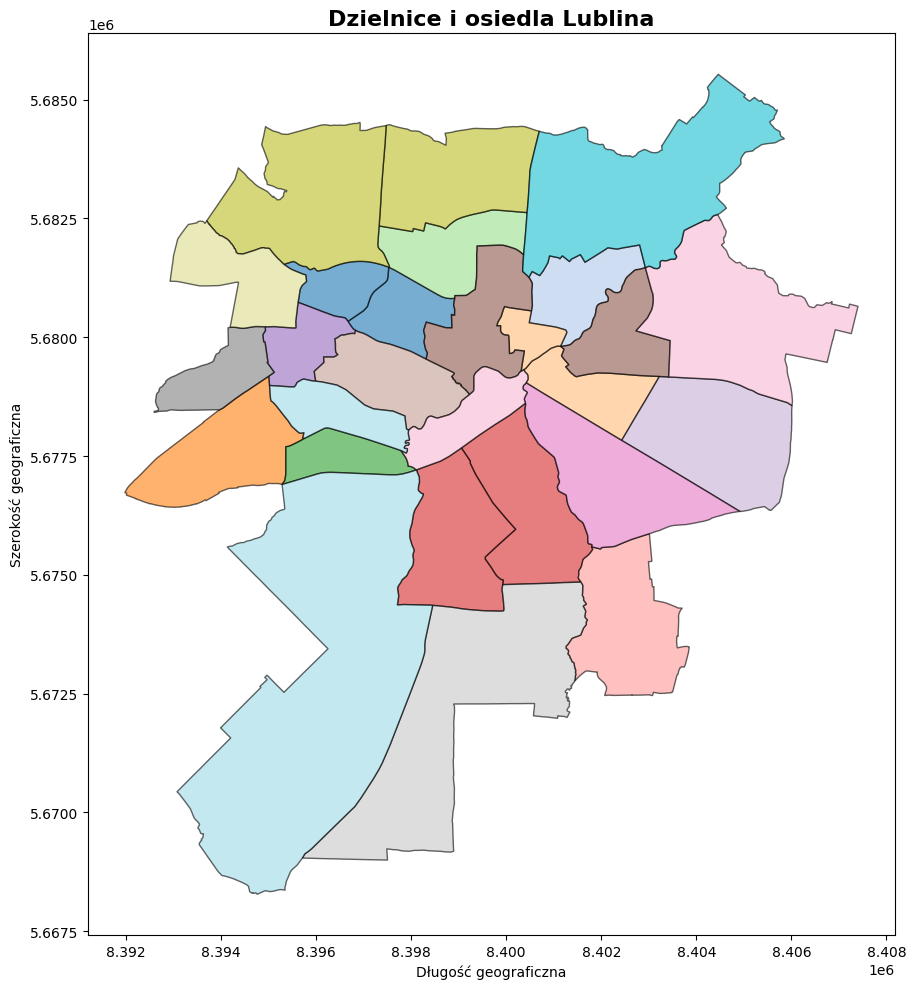

In [28]:
# Wizualizacja danych
import matplotlib.pyplot as plt

if gdf_data is not None and len(gdf_data) > 0:
    print("Tworzenie wizualizacji...\n")
    
    # Sprawdzenie czy są geometrie
    if 'geometry' in gdf_data.columns and gdf_data.geometry.notna().any():
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Rysowanie
        try:
            gdf_data.plot(ax=ax, alpha=0.6, edgecolor='black', cmap='tab20')
            
            # Dodanie nazw obiektów
            if 'name' in gdf_data.columns:
                for idx, row in gdf_data.iterrows():
                    if row.geometry.geom_type == 'Polygon':
                        centroid = row.geometry.centroid
                        ax.text(centroid.x, centroid.y, str(row['name'])[:15], 
                               fontsize=8, ha='center', bbox=dict(boxstyle='round', 
                               facecolor='wheat', alpha=0.5))
            
            plt.title('Dzielnice i osiedla Lublina', fontsize=16, fontweight='bold')
            plt.xlabel('Długość geograficzna')
            plt.ylabel('Szerokość geograficzna')
            plt.tight_layout()
            
            # Zapis mapy
            plt.savefig('dzielnice_lublin_mapa.png', dpi=150, bbox_inches='tight')
            print("✓ Mapa zapisana do: dzielnice_lublin_mapa.png")
            plt.show()
            
        except Exception as e:
            print(f"✗ Błąd przy tworzeniu mapy: {e}")
    else:
        print("Brak geometrii do wizualizacji - wyświetlam dane tabelaryczne:")
        print(gdf_data)
        
        # Zapisanie wykresu słupkowego z ilością rekordów
        fig, ax = plt.subplots(figsize=(12, 6))
        if 'admin_level' in gdf_data.columns:
            gdf_data['admin_level'].value_counts().plot(kind='bar', ax=ax)
            plt.title('Liczba obiektów po poziomie administracyjnym')
            plt.xlabel('Poziom administracyjny')
            plt.ylabel('Liczba')
            plt.tight_layout()
            plt.savefig('dzielnice_lublin_statystyka.png', dpi=150, bbox_inches='tight')
            print("✓ Statystyka zapisana do: dzielnice_lublin_statystyka.png")
            plt.show()
else:
    print("Brak danych do wizualizacji")


In [16]:
gdf_data

In [27]:
# Analiza geometrii dzielnic
print("=" * 80)
print("ANALIZA GEOMETRII DZIELNIC LUBLINA")
print("=" * 80)

if gdf_data is not None and len(gdf_data) > 0:
    # Podstawowe informacje
    print(f"\nŁączna liczba dzielnic/osiedli: {len(gdf_data)}")
    print(f"\nKolumny w danych: {list(gdf_data.columns)}")
    
    # Informacje o CRS (układ współrzędnych)
    print(f"\nUkład współrzędnych (CRS): {gdf_data.crs}")
    
    # Analiza geometrii
    print("\n" + "-" * 80)
    print("Typy geometrii:")
    print("-" * 80)
    geom_types = gdf_data.geometry.geom_type.value_counts()
    for geom_type, count in geom_types.items():
        print(f"  {geom_type}: {count}")
    
    # Szczegóły dla każdej dzielnicy
    print("\n" + "-" * 80)
    print("Szczegółowe informacje o dzielnicach:")
    print("-" * 80)
    
    geometry_info = []
    for idx, row in gdf_data.iterrows():
        geom = row.geometry
        info = {
            'ID': idx,
            'Nazwa': row.get('name', 'Unknown'),
            'Typ administracyjny': row.get('admin_level', 'N/A'),
            'Typ geometrii': geom.geom_type,
            'Ilość punktów': len(geom.exterior.coords) if hasattr(geom, 'exterior') else 'N/A',
            'Powierzchnia (°²)': round(geom.area, 6) if hasattr(geom, 'area') else 'N/A',
            'Obwód (°)': round(geom.length, 6) if hasattr(geom, 'length') else 'N/A',
            'Centroid X': round(geom.centroid.x, 6) if geom.geom_type == 'Polygon' else 'N/A',
            'Centroid Y': round(geom.centroid.y, 6) if geom.geom_type == 'Polygon' else 'N/A',
            'Bounds (minx, miny, maxx, maxy)': geom.bounds if hasattr(geom, 'bounds') else 'N/A'
        }
        geometry_info.append(info)
        
        print(f"\n{idx}. {info['Nazwa']}")
        print(f"   Typ administracyjny: {info['Typ administracyjny']}")
        print(f"   Typ geometrii: {info['Typ geometrii']}")
        print(f"   Ilość punktów: {info['Ilość punktów']}")
        print(f"   Powierzchnia: {info['Powierzchnia (°²)']} °²")
        print(f"   Obwód: {info['Obwód (°)']} °")
        print(f"   Centroid: ({info['Centroid X']}, {info['Centroid Y']})")
        print(f"   Bounds: {info['Bounds (minx, miny, maxx, maxy)']}")
    
    # Zapisz do DataFrame
    geometry_df = pd.DataFrame(geometry_info)
    print("\n" + "-" * 80)
    print("Tabelaryczne podsumowanie geometrii:")
    print("-" * 80)
    print(geometry_df.to_string())
    
    # Zapis do CSV
    geometry_df.to_csv('dzielnice_lublin_geometria.csv', index=False)
    print(f"\n✓ Informacje o geometriach zapisane do: dzielnice_lublin_geometria.csv")
    
    # Statystyki geometryczne
    print("\n" + "-" * 80)
    print("Statystyki geometryczne:")
    print("-" * 80)
    
    # Tylko dla wielokątów
    polygon_gdf = gdf_data[gdf_data.geometry.geom_type == 'Polygon']
    if len(polygon_gdf) > 0:
        areas = polygon_gdf.geometry.area
        lengths = polygon_gdf.geometry.length
        
        print(f"\nPowierzchnia (w stopniach²):")
        print(f"  Najmniejsza: {areas.min():.6f}")
        print(f"  Największa: {areas.max():.6f}")
        print(f"  Średnia: {areas.mean():.6f}")
        print(f"  Mediana: {areas.median():.6f}")
        
        print(f"\nObwód (w stopniach):")
        print(f"  Najmniejszy: {lengths.min():.6f}")
        print(f"  Największy: {lengths.max():.6f}")
        print(f"  Średni: {lengths.mean():.6f}")
        print(f"  Mediana: {lengths.median():.6f}")
    
    # Bounding Box całego miasta
    print(f"\nBounding Box całego miasta:")
    bounds = gdf_data.total_bounds
    print(f"  Min X (Długość): {bounds[0]:.6f}")
    print(f"  Min Y (Szerokość): {bounds[1]:.6f}")
    print(f"  Max X (Długość): {bounds[2]:.6f}")
    print(f"  Max Y (Szerokość): {bounds[3]:.6f}")
    
    print("\n" + "=" * 80)
else:
    print("Brak danych do analizy")


ANALIZA GEOMETRII DZIELNIC LUBLINA

Łączna liczba dzielnic/osiedli: 27

Kolumny w danych: ['gml_id', 'nazwa', 'info', 'geometry']

Układ współrzędnych (CRS): None

--------------------------------------------------------------------------------
Typy geometrii:
--------------------------------------------------------------------------------
  Polygon: 27

--------------------------------------------------------------------------------
Szczegółowe informacje o dzielnicach:
--------------------------------------------------------------------------------

0. Unknown
   Typ administracyjny: N/A
   Typ geometrii: Polygon
   Ilość punktów: 86
   Powierzchnia: 2190056.346917 °²
   Obwód: 6995.642509 °
   Centroid: (8397835.451698, 5680494.738499)
   Bounds: (8396672.33, 5679539.8, 8398915.85, 5681473.71)

1. Unknown
   Typ administracyjny: N/A
   Typ geometrii: Polygon
   Ilość punktów: 94
   Powierzchnia: 1656250.508509 °²
   Obwód: 6128.405068 °
   Centroid: (8396525.916544, 5681052.893095)


In [ ]:
# Przekształcenie współrzędnych do EPSG:2180 (układ współrzędnych dla Polski)
print("=" * 80)
print("PRZEKSZTAŁCENIE WSPÓŁRZĘDNYCH DO EPSG:2180")
print("=" * 80)

if gdf_data is not None and len(gdf_data) > 0:
    # Sprawdź obecny CRS
    print(f"\nObecny układ współrzędnych (CRS): {gdf_data.crs}")
    
    # Przekształć do EPSG:2180
    try:
        gdf_data_2180 = gdf_data.to_crs('EPSG:2180')
        print("✓ Przekształcenie do EPSG:2180 zakończone pomyślnie")
        print(f"Nowy CRS: {gdf_data_2180.crs}")
        
        # Zapisz przekształcone dane
        gdf_data_2180.to_file('dzielnice_lublin_epsg2180.geojson', driver='GeoJSON')
        gdf_data_2180.to_file('dzielnice_lublin_epsg2180.shp')
        print("✓ Przekształcone dane zapisane do: dzielnice_lublin_epsg2180.geojson i dzielnice_lublin_epsg2180.shp")
        
        # Analiza geometrii w nowym układzie (metry)
        print("\n" + "-" * 80)
        print("ANALIZA GEOMETRII W EPSG:2180 (metry)")
        print("-" * 80)
        
        geometry_info_2180 = []
        for idx, row in gdf_data_2180.iterrows():
            geom = row.geometry
            info = {
                'ID': idx,
                'Nazwa': row.get('name', 'Unknown'),
                'Typ administracyjny': row.get('admin_level', 'N/A'),
                'Typ geometrii': geom.geom_type,
                'Ilość punktów': len(geom.exterior.coords) if hasattr(geom, 'exterior') else 'N/A',
                'Powierzchnia (m²)': round(geom.area, 2) if hasattr(geom, 'area') else 'N/A',
                'Obwód (m)': round(geom.length, 2) if hasattr(geom, 'length') else 'N/A',
                'Centroid X': round(geom.centroid.x, 2) if geom.geom_type == 'Polygon' else 'N/A',
                'Centroid Y': round(geom.centroid.y, 2) if geom.geom_type == 'Polygon' else 'N/A',
                'Bounds (minx, miny, maxx, maxy)': geom.bounds if hasattr(geom, 'bounds') else 'N/A'
            }
            geometry_info_2180.append(info)
        
        # Zapisz do DataFrame
        geometry_df_2180 = pd.DataFrame(geometry_info_2180)
        geometry_df_2180.to_csv('dzielnice_lublin_geometria_epsg2180.csv', index=False)
        print("✓ Informacje o geometriach w EPSG:2180 zapisane do: dzielnice_lublin_geometria_epsg2180.csv")
        
        # Statystyki geometryczne w metrach
        polygon_gdf_2180 = gdf_data_2180[gdf_data_2180.geometry.geom_type == 'Polygon']
        if len(polygon_gdf_2180) > 0:
            areas = polygon_gdf_2180.geometry.area
            lengths = polygon_gdf_2180.geometry.length
            
            print(f"\nPowierzchnia (w metrach²):")
            print(f"  Najmniejsza: {areas.min():.2f}")
            print(f"  Największa: {areas.max():.2f}")
            print(f"  Średnia: {areas.mean():.2f}")
            print(f"  Mediana: {areas.median():.2f}")
            
            print(f"\nObwód (w metrach):")
            print(f"  Najmniejszy: {lengths.min():.2f}")
            print(f"  Największy: {lengths.max():.2f}")
            print(f"  Średni: {lengths.mean():.2f}")
            print(f"  Mediana: {lengths.median():.2f}")
        
        # Bounding Box całego miasta w metrach
        print(f"\nBounding Box całego miasta (EPSG:2180):")
        bounds = gdf_data_2180.total_bounds
        print(f"  Min X: {bounds[0]:.2f} m")
        print(f"  Min Y: {bounds[1]:.2f} m")
        print(f"  Max X: {bounds[2]:.2f} m")
        print(f"  Max Y: {bounds[3]:.2f} m")
        
        print("\n" + "=" * 80)
        
    except Exception as e:
        print(f"✗ Błąd podczas przekształcania CRS: {e}")
        import traceback
        traceback.print_exc()
else:
    print("Brak danych do przekształcenia")